In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


# Feature Selection

In [8]:
processed_data = pd.read_csv("files/processed_data.csv")
processed_data.head()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage,Company_Apple,...,GPU_model_Radeon R7 M440,GPU_model_Radeon R7 M445,GPU_model_Radeon R7 M460,GPU_model_Radeon R7 M465,GPU_model_Radeon R9 M385,GPU_model_Radeon RX 540,GPU_model_Radeon RX 550,GPU_model_Radeon RX 560,GPU_model_Radeon RX 580,GPU_model_UHD Graphics 620
0,0.385542,0.096774,0.169576,0.196741,0.482619,0.597701,0.518519,0.058824,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.385542,0.096774,0.162095,0.122353,0.029911,0.094828,0.333333,0.058824,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.662651,0.096774,0.291771,0.067679,0.223929,0.224138,0.592593,0.121569,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.638554,0.225806,0.284289,0.398895,0.611964,0.741379,0.666667,0.247059,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.385542,0.096774,0.169576,0.275038,0.482619,0.597701,0.814815,0.121569,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# does this feature provide useful information for predicting the target variable (Price_euros)?
# Using mutual information for feature importance
y = processed_data['Price_euros'] #target variable
X = processed_data.drop(columns=['Price_euros'])

mutual_info = mutual_info_regression(X, y) #measures how much information a feature provides about the target variable
print("\nMutual Information:\n", mutual_info)
mi_scores = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False) #sort features by importance
print("\nMutual Information Scores:\n", mi_scores)

top_features = mi_scores[mi_scores > 0.1].index  # not zero
selected_features_data = X[top_features] # select the top features

selected_features_data['Price_euros'] = y

selected_features_data.to_csv('files/selected_features_data.csv', index=False)
selected_features_data.head()


Mutual Information:
 [1.93410578e-01 4.87406160e-01 2.83210126e-01 2.65934243e-01
 2.60871195e-01 4.64583767e-01 3.71843348e-01 6.40996122e-02
 1.04354475e-02 5.54324594e-03 8.40284314e-03 1.50646507e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 8.20468458e-03
 0.00000000e+00 7.67506395e-03 1.63225233e-02 1.51118861e-02
 0.00000000e+00 1.51415256e-03 0.00000000e+00 3.46391891e-03
 2.56896380e-03 0.00000000e+00 0.00000000e+00 1.38183222e-02
 4.62868944e-03 0.00000000e+00 2.99004502e-03 0.00000000e+00
 2.05825834e-03 3.12995280e-03 1.21252793e-02 2.40694723e-03
 0.00000000e+00 4.69739482e-03 0.00000000e+00 0.00000000e+00
 0.00000000e+00 5.58860465e-03 0.00000000e+00 1.28698452e-03
 1.34528900e-02 3.67659942e-03 2.14112336e-03 0.00000000e+00
 1.77814033e-02 3.33063239e-03 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.85891443e-03 0.00000000e+00 5.08802585e-03
 1.87537502e-03 7.95045410e-03 0.00000000e+00 1.16217982e-02
 0.00000000e+00 0.00000000e+00 9.55514490e-03 0.00000000e+00
 3

,Ram,CPU_freq,PrimaryStorage,Weight,ScreenW,ScreenH,TypeName_Notebook,PrimaryStorageType_SSD,Inches,PrimaryStorageType_HDD,Screen_Standard,Screen_Full HD,Price_euros
0,0.096774,0.518519,0.058824,0.169576,0.482619,0.597701,0.0,1.0,0.385542,0.0,1.0,0.0,0.196741
1,0.096774,0.333333,0.058824,0.162095,0.029911,0.094828,0.0,0.0,0.385542,0.0,1.0,0.0,0.122353
2,0.096774,0.592593,0.121569,0.291771,0.223929,0.224138,1.0,1.0,0.662651,0.0,0.0,1.0,0.067679
3,0.225806,0.666667,0.247059,0.284289,0.611964,0.741379,0.0,1.0,0.638554,0.0,1.0,0.0,0.398895
4,0.096774,0.814815,0.121569,0.169576,0.482619,0.597701,0.0,1.0,0.385542,0.0,1.0,0.0,0.275038


# Data Visualization

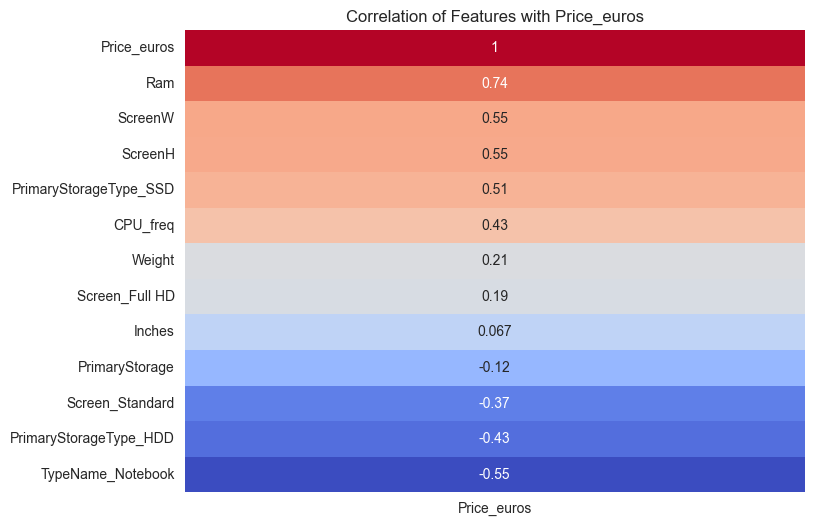

In [10]:
# Visualize correlations between features
plt.figure(figsize=(8, 6))
corr_with_price = selected_features_data.corr()['Price_euros'].sort_values(ascending=False)
sns.heatmap(corr_with_price.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Correlation of Features with Price_euros')
plt.show()

# Hypothesis Formulation

In [11]:
hypotheses = [
    "Laptops with more RAM tend to have higher prices.",
    "Screen size influences the price to a certain level.",
    "Laptops with a standard screen are cheaper."
]

print("Hypotheses about the data:\n")
for h in hypotheses:
    print("-", h)

Hypotheses about the data:

- Laptops with more RAM tend to have higher prices.
- Screen size influences the price to a certain level.
- Laptops with a standard screen are cheaper.
